# Figure 6 — ECM/cell-cycle dynamics and embryonic signature scoring

Plots:

- **a**: Stacked violin of ECM and cell-cycle marker genes across D1/D2/D4 × CTRL/EXP
- **h**: Embryonic signature score (Jacob et al., Dev Cell 2023) per FIB subcluster + EMB reference
- **i**: Embryonic signature score (Jacob et al.) — all fibroblasts pooled vs EMB reference
- **j**: Embryonic signature score (Phan et al., EMBO J 2023) per FIB subcluster + EMB reference
- **k**: Embryonic signature score (Phan et al.) — all fibroblasts pooled vs EMB reference

**Structure of this notebook**:
1. Imports / load `sub_fibroblasts.h5ad`
2. Panel a (uses only `sub_fibro`)
3. **Section H/I — Jacob et al. (Kasper)**: load Kasper reference → score → stats → panels h, i
4. **Section J/K — Phan et al. (Driskell)**: load+integrate Phan loom files → score → stats → panels j, k

Each reference block is self-contained so you can re-run one without redoing the other.

**Display renames** (matching manuscript axis labels):
- `obs['timepoint']`: `Day1`/`Day2`/`Day4` → `D1`/`D2`/`D4`
- `obs['condition']`: `Control`/`Expanded` → `CTRL`/`EXP`
- `obs['celltype']`: `Fibroblast 1–4` → `FIB1–FIB4`, `Embryonic fibroblasts` → `EMB`

## Imports

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Output directory for the saved figure SVGs
out_dir = Path('../manuscript_figures/figure_6')
out_dir.mkdir(parents=True, exist_ok=True)

sc.settings.set_figure_params(dpi=80, facecolor='white', frameon=False)

## Load in-vivo fibroblast data

Used by all panels. The two embryonic references are loaded in their own sections below.

In [5]:
sub_fibro = sc.read_h5ad('../../results/sub_fibroblasts.h5ad')
print(f'sub_fibro: {sub_fibro.n_obs} cells, {sub_fibro.n_vars} genes')

sub_fibro: 15419 cells, 32285 genes


## Colour palettes

Condition palette matches figure 1c/e (blue/orange), extended with a sage green for the
embryonic reference group used in panels h–k.

In [6]:
# ---- Condition palette (panels h-k) ----
# CTRL/EXP carry through from fig 1 for consistency; EMB added for the embryonic reference.
condition_cmap_emb = {
    'Control':   '#1F77B4',
    'Expanded':  '#FF7F0E',
    'Embryonic': '#8FCDB5',  # sage green
}

## Panel a — Stacked violin of ECM + cell-cycle markers across timepoint × condition

Same composite `timepoint × condition` grouping as figure 3a (D1 CTRL, D1 EXP, D2 CTRL,
D2 EXP, D4 CTRL, D4 EXP). Genes split conceptually into:

- **Collagens**: *Col1a1, Col1a2, Col3a1, Col4a1*
- **ECM**: *Fn1, Lum, Fbn1, Eln, Sparc, Fbln1*
- **Cell-cycle / proliferation**: *Pcna, Nasp, Slbp, Ctcf*

Colour = median expression in group (viridis). Uses log-normalized counts.

In [7]:
# Display renames (matches fig 3 convention)
timepoint_short = {
    'Day1': 'D1',
    'Day2': 'D2',
    'Day4': 'D4',
}
condition_short = {
    'Control':  'CTRL',
    'Expanded': 'EXP',
}

sub_fibro.obs['timepoint_short'] = (
    sub_fibro.obs['timepoint'].astype(str).replace(timepoint_short)
)
sub_fibro.obs['condition_short'] = (
    sub_fibro.obs['condition'].astype(str).replace(condition_short)
)
sub_fibro.obs['timepoint_condition'] = (
    sub_fibro.obs['timepoint_short'].astype(str)
    + ' '
    + sub_fibro.obs['condition_short'].astype(str)
)

# Order: D1 CTRL, D1 EXP, D2 CTRL, D2 EXP, D4 CTRL, D4 EXP
group_order = [
    'D1 CTRL', 'D1 EXP',
    'D2 CTRL', 'D2 EXP',
    'D4 CTRL', 'D4 EXP',
]

present = set(sub_fibro.obs['timepoint_condition'].unique())
missing_groups = [g for g in group_order if g not in present]
if missing_groups:
    print(f'WARNING: {len(missing_groups)} group(s) missing from data: {missing_groups}')

sub_fibro.obs['timepoint_condition'] = pd.Categorical(
    sub_fibro.obs['timepoint_condition'], categories=group_order, ordered=True,
)

print('\ntimepoint_condition counts:')
print(sub_fibro.obs['timepoint_condition'].value_counts().reindex(group_order))


timepoint_condition counts:
timepoint_condition
D1 CTRL    6230
D1 EXP     2056
D2 CTRL    2725
D2 EXP     1036
D4 CTRL    2679
D4 EXP      693
Name: count, dtype: int64


In [8]:
# Marker gene list (transcribed from the figure y-axis, top -> bottom)
panel_a_genes = [
    # Collagens
    'Col1a1', 'Col1a2', 'Col3a1', 'Col4a1',
    # Other ECM
    'Fn1', 'Lum', 'Fbn1', 'Eln', 'Sparc', 'Fbln1',
    # Cell-cycle / proliferation
    'Pcna', 'Nasp', 'Slbp', 'Ctcf',
]

missing = [g for g in panel_a_genes if g not in sub_fibro.var_names]
if missing:
    print(f'WARNING: {len(missing)} marker gene(s) not found in sub_fibro: {missing}')
genes_present = [g for g in panel_a_genes if g in sub_fibro.var_names]

In [32]:
sub_fibro.layers

Layers with keys: logcounts, rawcounts, scaled_counts

/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:325: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  row_ax = sns.violinplot(
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  row_ax = sns.violinplot(
/mnt/

/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  row_ax = sns.violinplot(
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  row_ax = sns.violinplot(
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  row_ax = sns.violinplot(
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: FutureWarning

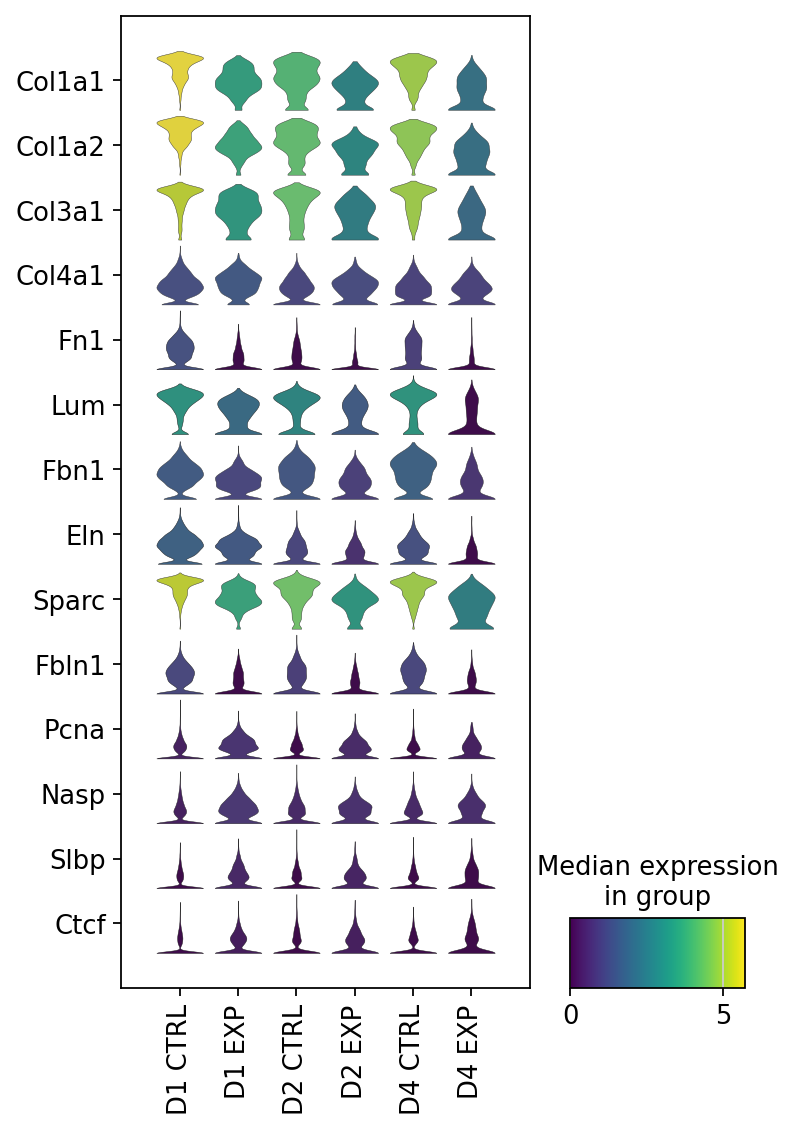

In [35]:
# Use log-normalized counts for visualization (not z-scored)
sub_fibro.X = sub_fibro.layers['logcounts']

sv = sc.pl.stacked_violin(
    sub_fibro,
    var_names=genes_present,
    groupby='timepoint_condition',
    categories_order=group_order,
    cmap='viridis',
    swap_axes=True,                # genes on y-axis, groups on x-axis (matches figure)
    figsize=(5, 8),
    return_fig=True,
    show=False,
)

sv = sv.style(
    cmap='viridis',                # repeat cmap (same gotcha as dotplot in fig 1f)
)

sv.savefig(out_dir / 'fig6a_stacked_violin_ecm_cellcycle.svg',
           dpi=300, bbox_inches='tight')
plt.show()

/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:325: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  row_ax = sns.violinplot(
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  row_ax = sns.violinplot(
/mnt/

/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  row_ax = sns.violinplot(
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  row_ax = sns.violinplot(
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  row_ax = sns.violinplot(


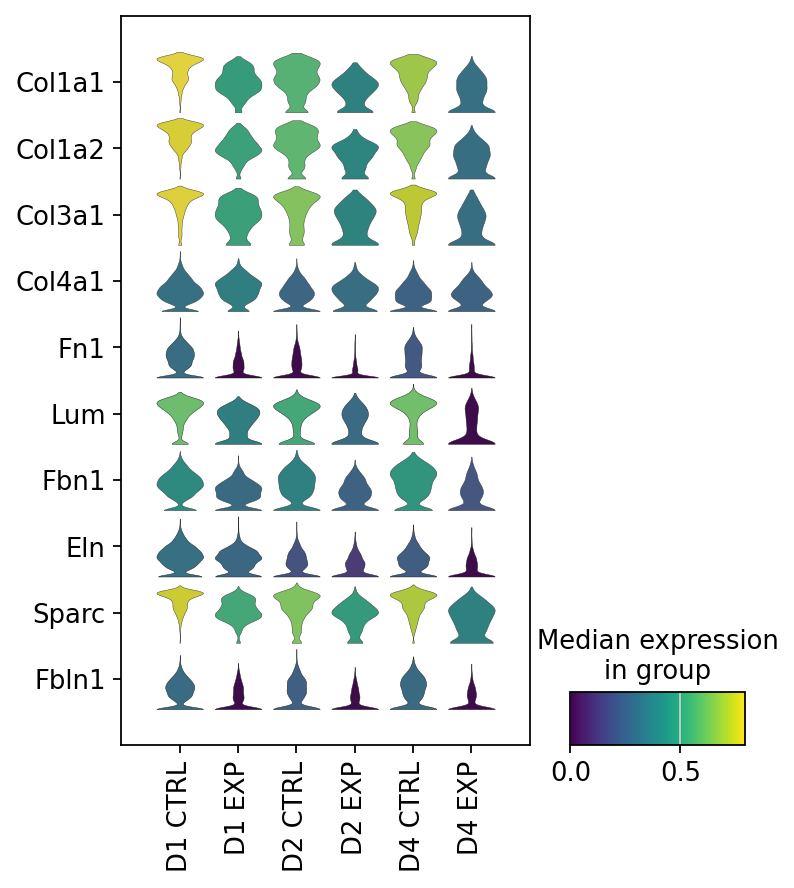

In [9]:
# Plot just the top 10 ECM genes with standard_scale='var'
ecm_genes = ['Col1a1','Col1a2','Col3a1','Col4a1','Fn1','Lum','Fbn1','Eln','Sparc','Fbln1']

sv = sc.pl.stacked_violin(
    sub_fibro,
    var_names=ecm_genes,
    groupby='timepoint_condition',
    categories_order=group_order,
    cmap='viridis',
    standard_scale='var',
    swap_axes=True,
    figsize=(5, 6),
    show=True,
)

/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:325: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  row_ax = sns.violinplot(
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  row_ax = sns.violinplot(
/mnt/

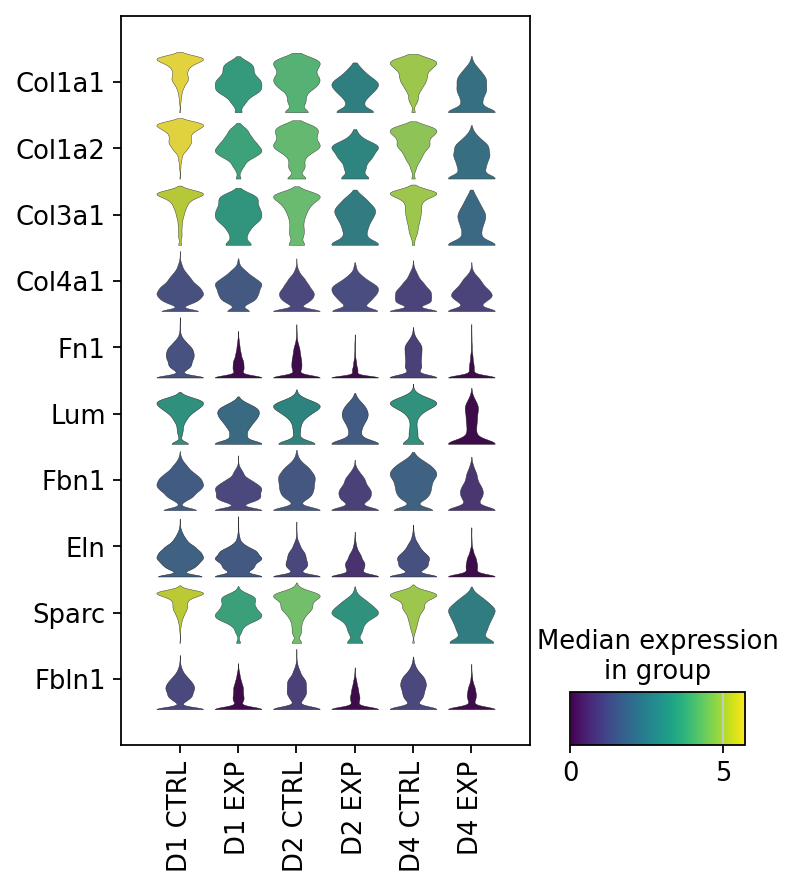

/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:325: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  row_ax = sns.violinplot(
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  row_ax = sns.violinplot(
/mnt/

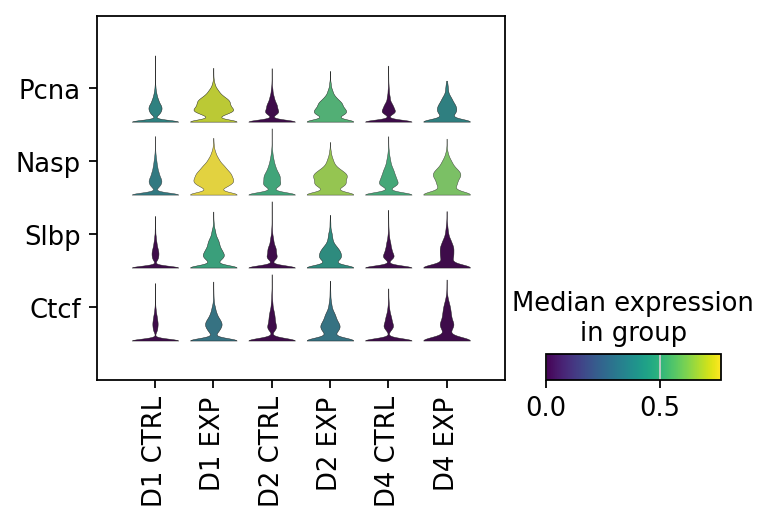

In [13]:
# Marker gene list (transcribed from the figure y-axis, top -> bottom)
# Split into two blocks: each block is rendered as its own stacked_violin so that
# `standard_scale='var'` rescales within the block. This is how the published figure
# was assembled (the two blocks were composited in Illustrator with a shared colorbar).
panel_a_genes_ecm = [
    # Collagens
    'Col1a1', 'Col1a2', 'Col3a1', 'Col4a1',
    # Other ECM
    'Fn1', 'Lum', 'Fbn1', 'Eln', 'Sparc', 'Fbln1',
]
panel_a_genes_cc = [
    # Cell-cycle / proliferation
    'Pcna', 'Nasp', 'Slbp', 'Ctcf',
]
panel_a_genes = panel_a_genes_ecm + panel_a_genes_cc

missing = [g for g in panel_a_genes if g not in sub_fibro.var_names]
if missing:
    print(f'WARNING: {len(missing)} marker gene(s) not found in sub_fibro: {missing}')
genes_ecm_present = [g for g in panel_a_genes_ecm if g in sub_fibro.var_names]
genes_cc_present  = [g for g in panel_a_genes_cc  if g in sub_fibro.var_names]

# Use log-normalized counts for visualization (not z-scored)
sub_fibro.X = sub_fibro.layers['logcounts']

# ---- Top block: ECM / collagen genes ----
# Each gene row is independently 0-1 normalized across the 6 groups (standard_scale='var')
sv_ecm = sc.pl.stacked_violin(
    sub_fibro,
    var_names=genes_ecm_present,
    groupby='timepoint_condition',
    categories_order=group_order,
    cmap='viridis',
    swap_axes=True,
    figsize=(5, 6),
    return_fig=True,
    show=False,
)
sv_ecm = sv_ecm.style(cmap='viridis',)
sv_ecm.savefig(out_dir / 'fig6a_top_stacked_violin_ecm.svg',
               dpi=300, bbox_inches='tight')
plt.show()

# ---- Bottom block: cell-cycle / proliferation genes ----
# Separate plot so cell-cycle genes get their own row-normalization range; without this,
# the shared colorbar would wash out the cell-cycle rows (the issue we hit empirically).
sv_cc = sc.pl.stacked_violin(
    sub_fibro,
    var_names=genes_cc_present,
    groupby='timepoint_condition',
    categories_order=group_order,
    cmap='viridis',
    swap_axes=True,
    figsize=(5, 3),
    return_fig=True,
    show=False,
)
sv_cc = sv_cc.style(cmap='viridis',)
sv_cc.savefig(out_dir / 'fig6a_bottom_stacked_violin_cellcycle.svg',
              dpi=300, bbox_inches='tight')
plt.show()

# The two SVGs are composited in Illustrator: stack vertically, align the x-axis,
# drop the duplicate x-tick labels from the top plot, and show a single colorbar
# (typically the bottom plot's, since cell-cycle is the analytical focus of the panel).

## Shared stats helpers (panels h–k)

For each reference: score the marker list on the in-vivo FIB1–FIB4 subset and on the
embryonic reference, combine into a single DataFrame, and run two-sided Mann-Whitney U
(EXP vs CTRL) per subcluster with BH correction across the 4 subclusters. Panels i/k pool
all fibroblasts into a single test (no correction — single comparison).

In [8]:
# ---- Per-subcluster stats (shared by panels h and j) ----
celltypes = [
    ('Fibroblast 1', 0),
    ('Fibroblast 2', 1),
    ('Fibroblast 3', 2),
    ('Fibroblast 4', 3),
]

# Short display names for the x-axis (FIB1, FIB2, FIB3, FIB4, EMB)
celltype_short = {
    'Fibroblast 1':          'FIB1',
    'Fibroblast 2':          'FIB2',
    'Fibroblast 3':          'FIB3',
    'Fibroblast 4':          'FIB4',
    'Embryonic fibroblasts': 'EMB',
}

def get_pvals_and_U(df, celltypes):
    """Two-sided Mann-Whitney U for Expanded vs Control within each subcluster."""
    pvals, Us, n_exp, n_ctrl = [], [], [], []
    for ct, _ in celltypes:
        expanded = df[(df['celltype'] == ct) & (df['condition'] == 'Expanded')]['embryonic_score']
        control  = df[(df['celltype'] == ct) & (df['condition'] == 'Control')]['embryonic_score']
        if len(expanded) == 0 or len(control) == 0:
            pvals.append(1.0); Us.append(float('nan'))
        else:
            U, p = mannwhitneyu(expanded, control, alternative='two-sided')
            pvals.append(p); Us.append(U)
        n_exp.append(len(expanded)); n_ctrl.append(len(control))
    return pvals, Us, n_exp, n_ctrl

def pval_stars(p):
    if   p < 1e-4: return '****'
    elif p < 1e-3: return '***'
    elif p < 1e-2: return '**'
    elif p < 0.05: return '*'
    else:          return 'ns'

def format_p_sci(p):
    """Format p-value as 'p=4.26x10^-61' style."""
    if p == 0 or p < 1e-300:
        return r'p=$10^{-300}$'
    mantissa, exp = f'{p:.2e}'.split('e')
    exp = int(exp)
    return rf'p={mantissa}×10$^{{{exp}}}$'

def annotate_per_subcluster(ax, df_subc, celltypes, pvals_corr, n_per_box):
    """Annotate per-subcluster boxes with stars + exact P + n=cells.

    n_per_box: list of (n_ctrl, n_exp) tuples in `celltypes` order.
    The EMB box (rightmost) gets only n=cells (no comparison).
    """
    y_max_overall = df_subc['embryonic_score'].max()
    bracket_y = y_max_overall + 0.05
    text_y    = y_max_overall + 0.07
    p_y       = y_max_overall + 0.16
    n_y       = y_max_overall + 0.22

    for (ct, xpos), p, (n_c, n_e) in zip(celltypes, pvals_corr, n_per_box):
        stars = pval_stars(p)
        ax.plot([xpos - 0.2, xpos + 0.2], [bracket_y]*2, color='black', linewidth=1.0)
        ax.text(xpos, text_y, stars, ha='center', va='bottom', fontsize=11)
        ax.text(xpos, p_y, format_p_sci(p), ha='center', va='bottom', fontsize=7)
        ax.text(xpos, n_y, f'n={n_c + n_e}', ha='center', va='bottom', fontsize=7, style='italic')

# Section H/I — Jacob et al. (Kasper) reference

## Load Kasper reference

Reads the pre-built Kasper AnnData objects (preprocessed upstream, see
`skin_expansion_Github.ipynb` section 17.1). `kasperfib` is the fibroblast-only subset
with `leiden_named` annotation already attached.

In [15]:
kasperfib  = sc.read_h5ad('../../data/Data_to_integrate/Kasper/Adata-object_Fib.h5?download=1')
# Marker list

kasper_markers = pd.read_csv('../../data/Embryonic_markers_Kasper.csv')
kasper_genes   = [g for g in pd.unique(kasper_markers.values.ravel()) if pd.notnull(g)]

print(f'kasperfib:  {kasperfib.n_obs} cells')
print(f'Kasper signature: {len(kasper_genes)} genes')

kasperfib:  25944 cells
Kasper signature: 473 genes


### Score Jacob et al. (Kasper) signature

In [16]:
# ---- Score in-vivo fibroblast subclusters (FIB1-FIB4) ----
sub_fibro_k = sub_fibro[sub_fibro.obs['celltype'].isin(
    ['Fibroblast 1', 'Fibroblast 2', 'Fibroblast 3', 'Fibroblast 4']
)].copy()
sub_fibro_k.X = sub_fibro_k.layers['scaled_counts']
sc.tl.score_genes(sub_fibro_k, gene_list=kasper_genes, score_name='embryonic_score')

sub_fibro_k.obs['condition'] = pd.Categorical(
    sub_fibro_k.obs['condition'].astype(str),
    categories=['Control', 'Expanded'], ordered=True,
)
sub_fibro_k.obs['celltype'] = pd.Categorical(
    sub_fibro_k.obs['celltype'],
    categories=['Fibroblast 1', 'Fibroblast 2', 'Fibroblast 3', 'Fibroblast 4'],
    ordered=True,
)

# ---- Score Kasper embryonic-fibroblast reference ----
embryo_fib_k = kasperfib[kasperfib.obs['leiden_named'].isin([
    'FIB Origin1', 'FIB Origin2', 'FIB Origin3', 'FIB Origin4', 'FIB Origin5', 'FIB Origin6'
])].copy()
sc.tl.score_genes(embryo_fib_k, gene_list=kasper_genes, score_name='embryonic_score')
embryo_fib_k.obs['celltype']  = 'Embryonic fibroblasts'
embryo_fib_k.obs['condition'] = 'Embryonic'

print(f'EMB reference (Jacob/Kasper) n = {embryo_fib_k.n_obs} cells')

# ---- Combine for plotting ----
combined_k = pd.concat([
    sub_fibro_k.obs[['embryonic_score', 'celltype', 'condition']],
    embryo_fib_k.obs[['embryonic_score', 'celltype', 'condition']],
])
combined_k['condition'] = pd.Categorical(
    combined_k['condition'],
    categories=['Control', 'Expanded', 'Embryonic'], ordered=True,
)

# ---- Per-subcluster stats ----
raw_pvals_k, U_stats_k, n_exp_k, n_ctrl_k = get_pvals_and_U(sub_fibro_k.obs, celltypes)
_, corrected_pvals_k, _, _ = multipletests(raw_pvals_k, method='fdr_bh')

print('\n=== Kasper: Per-subcluster results (two-sided Mann-Whitney U, BH-corrected) ===')
print(f'{"Subcluster":<18} {"n_EXP":<8} {"n_CTRL":<8} {"U":<14} {"Raw p":<15} {"BH-adj p":<15}')
for (ct, _), U, raw_p, corr_p, ne, nc in zip(
        celltypes, U_stats_k, raw_pvals_k, corrected_pvals_k, n_exp_k, n_ctrl_k):
    print(f'{ct:<18} {ne:<8} {nc:<8} {U:<14.0f} {raw_p:<15.3e} {corr_p:<15.3e}')

EMB reference (Jacob/Kasper) n = 8146 cells

=== Kasper: Per-subcluster results (two-sided Mann-Whitney U, BH-corrected) ===
Subcluster         n_EXP    n_CTRL   U              Raw p           BH-adj p       
Fibroblast 1       353      1735     476940         2.128e-61       4.255e-61      
Fibroblast 2       149      2215     295903         3.159e-59       4.211e-59      
Fibroblast 3       424      2435     841052         2.948e-95       1.179e-94      
Fibroblast 4       289      131      30054          4.812e-22       4.812e-22      


## Panel h — Kasper embryonic score per FIB subcluster

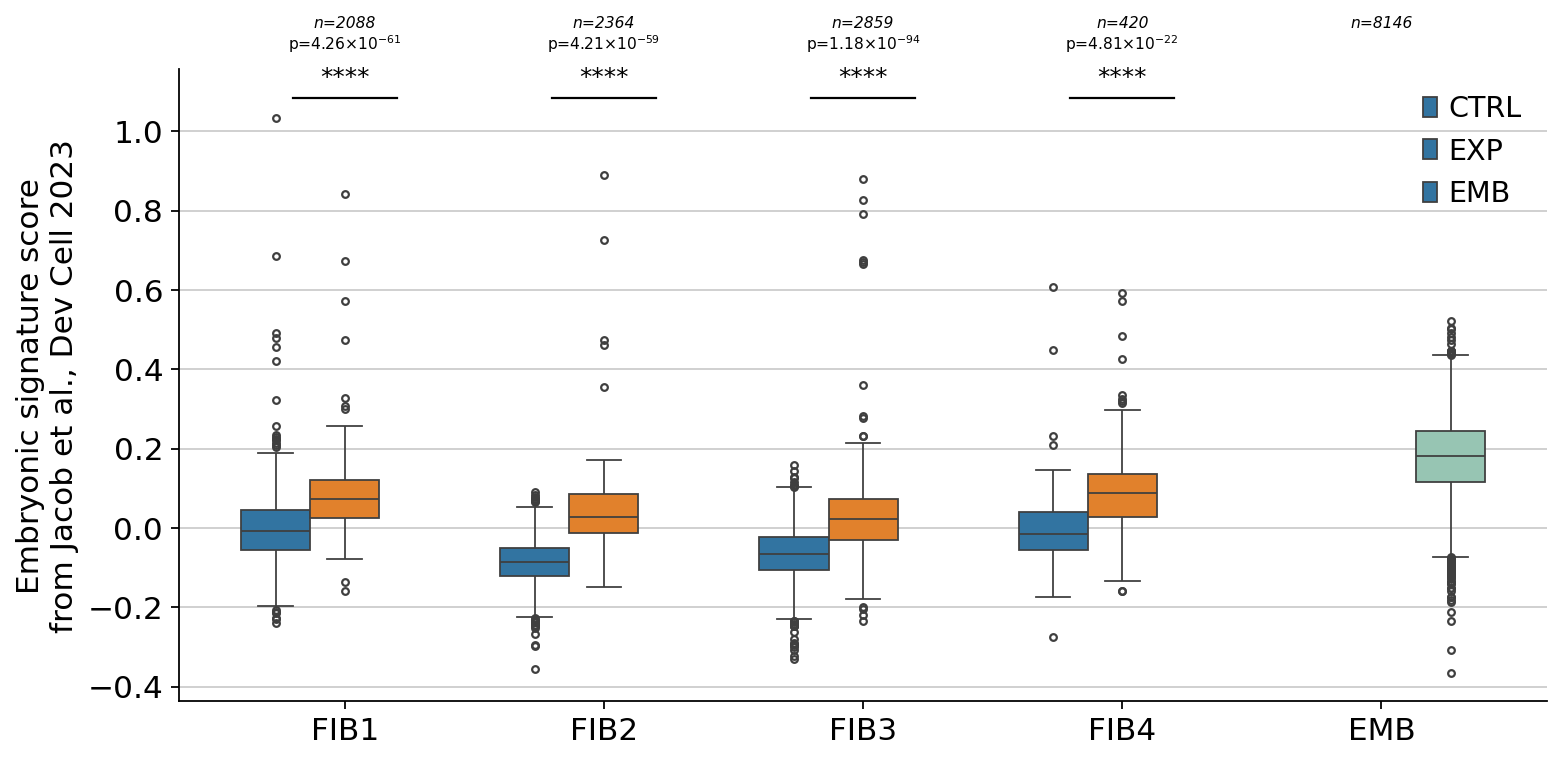

In [17]:
df_h = combined_k[combined_k['celltype'].isin([
    'Fibroblast 1', 'Fibroblast 2', 'Fibroblast 3', 'Fibroblast 4', 'Embryonic fibroblasts'
])].copy()
df_h['celltype_short'] = df_h['celltype'].astype(str).replace(celltype_short)
df_h['celltype_short'] = pd.Categorical(
    df_h['celltype_short'],
    categories=['FIB1', 'FIB2', 'FIB3', 'FIB4', 'EMB'],
    ordered=True,
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df_h, x='celltype_short', y='embryonic_score', hue='condition',
    palette=condition_cmap_emb, ax=ax,
    fliersize=3, linewidth=0.8,
)

# Per-subcluster annotations (stars + p + n=cells); EMB box gets only n=cells
n_per_box = list(zip(n_ctrl_k, n_exp_k))
annotate_per_subcluster(ax, df_h, celltypes, corrected_pvals_k, n_per_box)

# n=cells annotation for the EMB box
y_max_overall = df_h['embryonic_score'].max()
n_emb = int((df_h['celltype_short'] == 'EMB').sum())
ax.text(4, y_max_overall + 0.22, f'n={n_emb}', ha='center', va='bottom',
        fontsize=7, style='italic')

ax.set_xlabel('')
ax.set_ylabel('Embryonic signature score\nfrom Jacob et al., Dev Cell 2023')
ax.legend(title=None, loc='upper right', frameon=False,
          labels=['CTRL', 'EXP', 'EMB'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(out_dir / 'fig6h_embryonic_score_kasper_per_subcluster.svg',
            dpi=300, bbox_inches='tight', transparent=True)
df_h.to_csv(out_dir / 'fig6h_source_data.csv', index=False)
plt.show()

## Panel i — Kasper embryonic score, all fibroblasts pooled

Single comparison (EXP vs CTRL), so no multiple-testing correction.


=== Plot i (Kasper, all fibroblasts): two-sided Mann-Whitney U ===
n_EXP=1215, n_CTRL=6516, n_EMB=8146, U=6675600, p=0.000000e+00


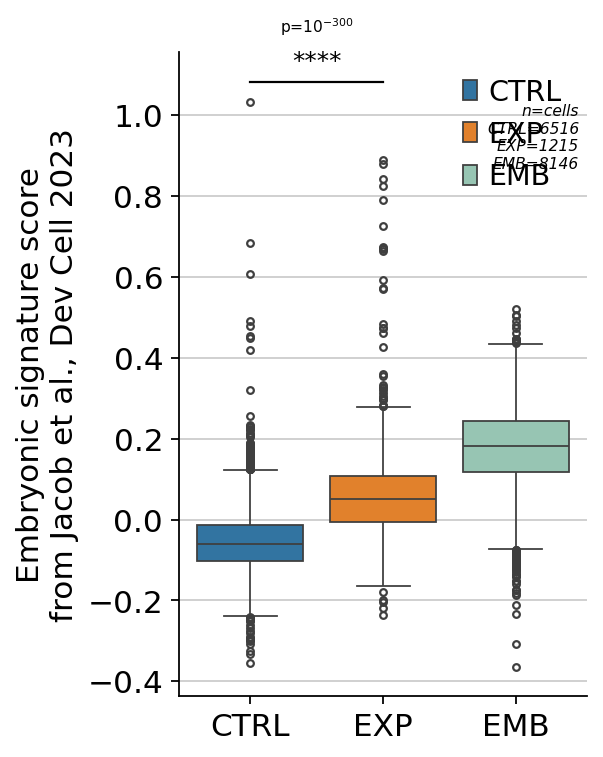

In [18]:
df_i = combined_k.copy()
df_i.loc[df_i['celltype'].astype(str).str.startswith('Fibroblast'), 'celltype'] = 'All fibroblasts'
df_i['celltype'] = pd.Categorical(
    df_i['celltype'], categories=['All fibroblasts', 'Embryonic fibroblasts'], ordered=True,
)

# All-fibroblasts stat (EXP vs CTRL only; EMB doesn't enter the test)
expanded = df_i[(df_i['celltype'] == 'All fibroblasts') & (df_i['condition'] == 'Expanded')]['embryonic_score']
control  = df_i[(df_i['celltype'] == 'All fibroblasts') & (df_i['condition'] == 'Control')]['embryonic_score']
U_i, p_i = mannwhitneyu(expanded, control, alternative='two-sided')

n_ctrl_i = len(control)
n_exp_i  = len(expanded)
n_emb_i  = int((df_i['celltype'] == 'Embryonic fibroblasts').sum())

print(f'\n=== Plot i (Kasper, all fibroblasts): two-sided Mann-Whitney U ===')
print(f'n_EXP={n_exp_i}, n_CTRL={n_ctrl_i}, n_EMB={n_emb_i}, U={U_i:.0f}, p={p_i:.6e}')

# Reshape so each box is one (celltype, condition) pair: CTRL, EXP, EMB on the x-axis
df_i_plot = df_i.copy()
df_i_plot['x_group'] = np.where(
    df_i_plot['celltype'] == 'Embryonic fibroblasts',
    'EMB',
    df_i_plot['condition'].astype(str).replace(condition_short),
)
df_i_plot['x_group'] = pd.Categorical(
    df_i_plot['x_group'], categories=['CTRL', 'EXP', 'EMB'], ordered=True,
)
# Map each x_group to its corresponding original 'condition' for coloring
xgroup_to_cond = {'CTRL': 'Control', 'EXP': 'Expanded', 'EMB': 'Embryonic'}
df_i_plot['color_cond'] = df_i_plot['x_group'].astype(str).replace(xgroup_to_cond)

fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(
    data=df_i_plot, x='x_group', y='embryonic_score', hue='color_cond',
    palette=condition_cmap_emb,
    hue_order=['Control', 'Expanded', 'Embryonic'],
    dodge=False, ax=ax,
    fliersize=3, linewidth=0.8,
)

# Annotate the CTRL vs EXP comparison only
stars_i = pval_stars(p_i)
y_max_i = df_i_plot['embryonic_score'].max()
ax.plot([0, 1], [y_max_i + 0.05]*2, color='black', linewidth=1.0)
ax.text(0.5, y_max_i + 0.07, stars_i, ha='center', va='bottom', fontsize=11)
ax.text(0.5, y_max_i + 0.16, format_p_sci(p_i), ha='center', va='bottom', fontsize=7)

# n=cells annotations (top-right corner)
ax.text(0.98, 0.92, f'n=cells\nCTRL={n_ctrl_i}\nEXP={n_exp_i}\nEMB={n_emb_i}',
        transform=ax.transAxes, ha='right', va='top', fontsize=7, style='italic')

ax.set_xlabel('')
ax.set_ylabel('Embryonic signature score\nfrom Jacob et al., Dev Cell 2023')
ax.legend(title=None, loc='upper right', frameon=False,
          labels=['CTRL', 'EXP', 'EMB'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(out_dir / 'fig6i_embryonic_score_kasper_pooled.svg',
            dpi=300, bbox_inches='tight', transparent=True)
df_i_plot.to_csv(out_dir / 'fig6i_source_data.csv', index=False)
plt.show()

# Section J/K — Phan et al. (Driskell) reference

## Load + integrate Phan/Driskell loom files

Three developmental timepoints (E14, E17, P5) from Phan et al. (EMBO J 2023). QC-filter,
normalize, integrate with Scanorama, cluster, and extract the fibroblast clusters into
`phan_fib`.

This is the same procedure as section 18.1 of `skin_expansion_Github.ipynb`.

In [9]:
import scanorama

e14 = sc.read_loom('../../data/Feeder_scdata/GSM7093921_e14.loom')
e17 = sc.read_loom('../../data/Feeder_scdata/GSM7093922_e17.loom')
p5  = sc.read_loom('../../data/Feeder_scdata/GSM7093923_p05.loom')

for d in (e14, e17, p5):
    d.var_names_make_unique()

phan_adata = e14.concatenate(e17, p5, batch_key='Time', batch_categories=['E14', 'E17', 'P5'])

# QC
phan_adata.var['mt'] = phan_adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(phan_adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
phan_adata = phan_adata[
    (phan_adata.obs.n_genes_by_counts > 700)
    & (phan_adata.obs.n_genes_by_counts < 5000)
    & (phan_adata.obs.pct_counts_mt < 10), :
]

# Normalize + HVGs
sc.pp.normalize_total(phan_adata)
sc.pp.log1p(phan_adata)
sc.pp.highly_variable_genes(phan_adata, n_top_genes=4000)
var_genes = phan_adata.var.highly_variable

# Scanorama integration on per-batch HVG subsets
adatas_per_batch = [phan_adata[phan_adata.obs['Time'] == b, var_genes]
                    for b in phan_adata.obs['Time'].cat.categories]
scanorama.integrate_scanpy(adatas_per_batch, dimred=50)
phan_adata.obsm['Scanorama'] = np.concatenate([a.obsm['X_scanorama'] for a in adatas_per_batch])

# Neighbors / UMAP / Leiden
sc.pp.neighbors(phan_adata, n_pcs=50, use_rep='Scanorama')
sc.tl.umap(phan_adata)
sc.tl.leiden(phan_adata, resolution=1, random_state=3)

# Fibroblast clusters (manually identified in section 18.1)
phan_fib = phan_adata[phan_adata.obs['leiden'].isin(
    ['0', '2', '3', '5', '11', '14', '16', '17', '18', '23']
)].copy()

# Marker list
phan_markers = pd.read_csv('../../data/Embryonic_markers_Phan_et_al.csv', header=None)
phan_genes   = [g for g in pd.unique(phan_markers.values.ravel()) if pd.notnull(g)]

print(f'phan_adata: {phan_adata.n_obs} cells (post-QC, all clusters)')
print(f'phan_fib:   {phan_fib.n_obs} cells (fibroblast clusters)')
print(f'Phan signature: {len(phan_genes)} genes')

/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/loompy/bus_file.py:68: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def twobit_to_dna(twobit: int, size: int) -> str:
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/loompy/bus_file.py:85: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def dna_to_twobit(dna: str) -> i

Found 4000 genes among all datasets
[[0.         0.47083391 0.05746124]
 [0.         0.         0.43923152]
 [0.         0.         0.        ]]
Processing datasets (0, 1)
Processing datasets (1, 2)


/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/scanorama/scanorama.py:284: ImplicitModificationWarning: Setting element `.obsm['X_scanorama']` of view, initializing view as actual.
  adata.obsm['X_scanorama'] = X_dimred
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/mnt/data/miniconda3/envs/scanpy_reticulate/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be ch

phan_adata: 35935 cells (post-QC, all clusters)
phan_fib:   15348 cells (fibroblast clusters)
Phan signature: 849 genes


### Score Phan et al. (Driskell) signature

In [10]:
# ---- Score in-vivo fibroblast subclusters (FIB1-FIB4) ----
sub_fibro_p = sub_fibro[sub_fibro.obs['celltype'].isin(
    ['Fibroblast 1', 'Fibroblast 2', 'Fibroblast 3', 'Fibroblast 4']
)].copy()
sub_fibro_p.X = sub_fibro_p.layers['scaled_counts']
sc.tl.score_genes(sub_fibro_p, gene_list=phan_genes, score_name='embryonic_score')

sub_fibro_p.obs['condition'] = pd.Categorical(
    sub_fibro_p.obs['condition'].astype(str),
    categories=['Control', 'Expanded'], ordered=True,
)
sub_fibro_p.obs['celltype'] = pd.Categorical(
    sub_fibro_p.obs['celltype'],
    categories=['Fibroblast 1', 'Fibroblast 2', 'Fibroblast 3', 'Fibroblast 4'],
    ordered=True,
)

# ---- Score Phan/Driskell embryonic reference (E14) ----
embryo_fib_p = phan_fib[phan_fib.obs['Time'] == 'E14'].copy()
sc.tl.score_genes(embryo_fib_p, gene_list=phan_genes, score_name='embryonic_score')
embryo_fib_p.obs['celltype']  = 'Embryonic fibroblasts'
embryo_fib_p.obs['condition'] = 'Embryonic'

print(f'EMB reference (Phan/Driskell, E14) n = {embryo_fib_p.n_obs} cells')

# ---- Combine for plotting ----
combined_p = pd.concat([
    sub_fibro_p.obs[['embryonic_score', 'celltype', 'condition']],
    embryo_fib_p.obs[['embryonic_score', 'celltype', 'condition']],
])
combined_p['condition'] = pd.Categorical(
    combined_p['condition'],
    categories=['Control', 'Expanded', 'Embryonic'], ordered=True,
)

# ---- Per-subcluster stats ----
raw_pvals_p, U_stats_p, n_exp_p, n_ctrl_p = get_pvals_and_U(sub_fibro_p.obs, celltypes)
_, corrected_pvals_p, _, _ = multipletests(raw_pvals_p, method='fdr_bh')

print('\n=== Phan: Per-subcluster results (two-sided Mann-Whitney U, BH-corrected) ===')
print(f'{"Subcluster":<18} {"n_EXP":<8} {"n_CTRL":<8} {"U":<14} {"Raw p":<15} {"BH-adj p":<15}')
for (ct, _), U, raw_p, corr_p, ne, nc in zip(
        celltypes, U_stats_p, raw_pvals_p, corrected_pvals_p, n_exp_p, n_ctrl_p):
    print(f'{ct:<18} {ne:<8} {nc:<8} {U:<14.0f} {raw_p:<15.3e} {corr_p:<15.3e}')

EMB reference (Phan/Driskell, E14) n = 5765 cells

=== Phan: Per-subcluster results (two-sided Mann-Whitney U, BH-corrected) ===
Subcluster         n_EXP    n_CTRL   U              Raw p           BH-adj p       
Fibroblast 1       353      1735     522779         1.176e-97       2.353e-97      
Fibroblast 2       149      2215     305675         4.072e-68       5.430e-68      
Fibroblast 3       424      2435     912849         4.697e-141      1.879e-140     
Fibroblast 4       289      131      26300          1.607e-10       1.607e-10      


## Panel j — Phan embryonic score per FIB subcluster

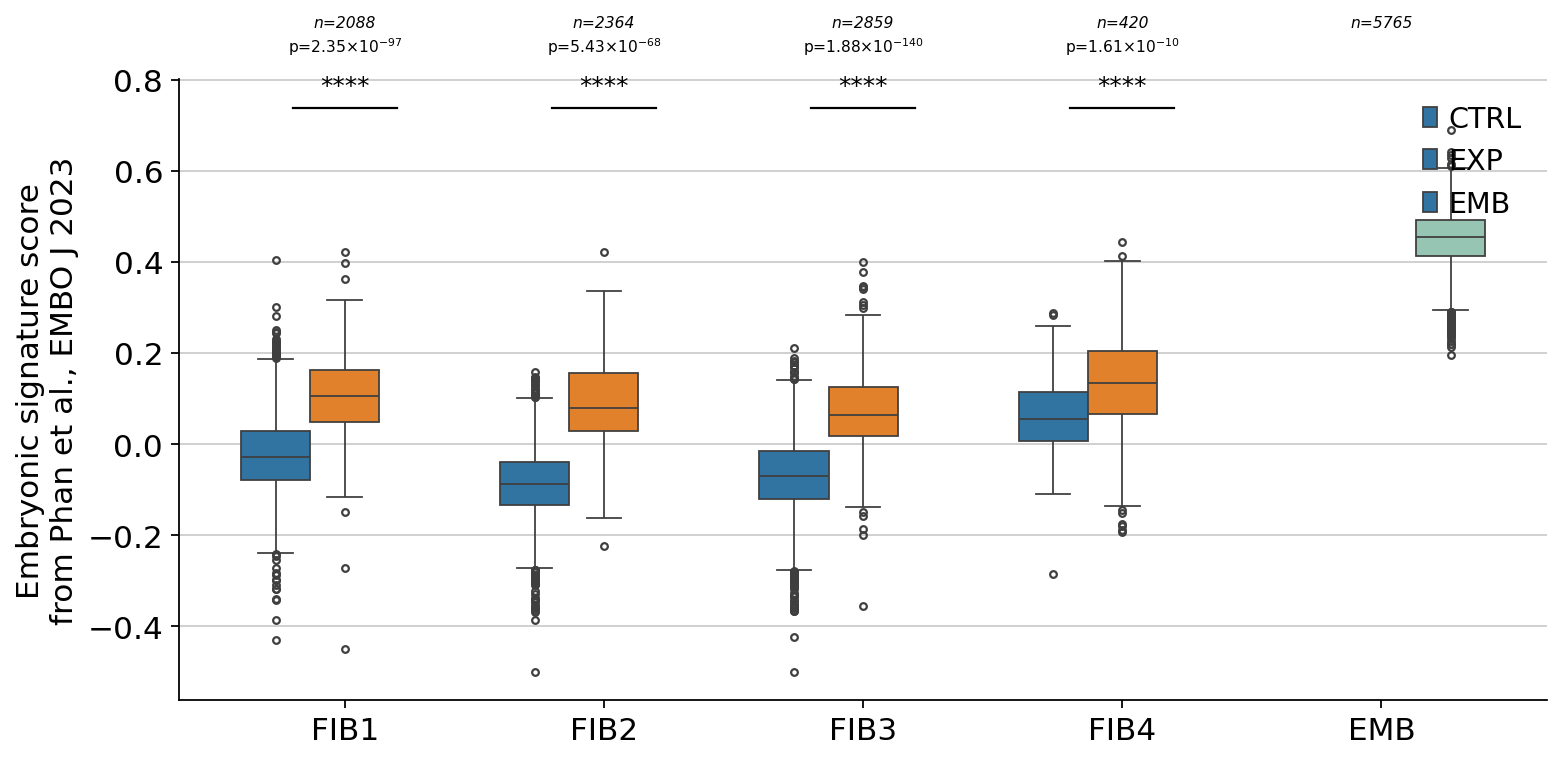

In [11]:
df_j = combined_p[combined_p['celltype'].isin([
    'Fibroblast 1', 'Fibroblast 2', 'Fibroblast 3', 'Fibroblast 4', 'Embryonic fibroblasts'
])].copy()
df_j['celltype_short'] = df_j['celltype'].astype(str).replace(celltype_short)
df_j['celltype_short'] = pd.Categorical(
    df_j['celltype_short'],
    categories=['FIB1', 'FIB2', 'FIB3', 'FIB4', 'EMB'],
    ordered=True,
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df_j, x='celltype_short', y='embryonic_score', hue='condition',
    palette=condition_cmap_emb, ax=ax,
    fliersize=3, linewidth=0.8,
)

n_per_box = list(zip(n_ctrl_p, n_exp_p))
annotate_per_subcluster(ax, df_j, celltypes, corrected_pvals_p, n_per_box)

y_max_overall = df_j['embryonic_score'].max()
n_emb = int((df_j['celltype_short'] == 'EMB').sum())
ax.text(4, y_max_overall + 0.22, f'n={n_emb}', ha='center', va='bottom',
        fontsize=7, style='italic')

ax.set_xlabel('')
ax.set_ylabel('Embryonic signature score\nfrom Phan et al., EMBO J 2023')
ax.legend(title=None, loc='upper right', frameon=False,
          labels=['CTRL', 'EXP', 'EMB'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(out_dir / 'fig6j_embryonic_score_phan_per_subcluster.svg',
            dpi=300, bbox_inches='tight', transparent=True)
df_j.to_csv(out_dir / 'fig6j_source_data.csv', index=False)
plt.show()

## Panel k — Phan embryonic score, all fibroblasts pooled


=== Plot k (Phan, all fibroblasts): two-sided Mann-Whitney U ===
n_EXP=1215, n_CTRL=6516, n_EMB=5765, U=7037239, p=0.000000e+00


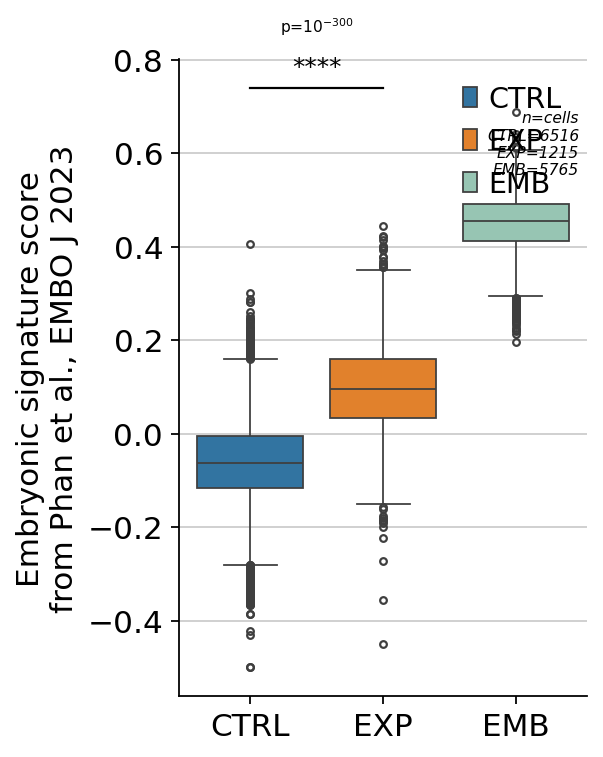

In [19]:
df_k = combined_p.copy()
df_k.loc[df_k['celltype'].astype(str).str.startswith('Fibroblast'), 'celltype'] = 'All fibroblasts'
df_k['celltype'] = pd.Categorical(
    df_k['celltype'], categories=['All fibroblasts', 'Embryonic fibroblasts'], ordered=True,
)

expanded = df_k[(df_k['celltype'] == 'All fibroblasts') & (df_k['condition'] == 'Expanded')]['embryonic_score']
control  = df_k[(df_k['celltype'] == 'All fibroblasts') & (df_k['condition'] == 'Control')]['embryonic_score']
U_k, p_k = mannwhitneyu(expanded, control, alternative='two-sided')

n_ctrl_k_pool = len(control)
n_exp_k_pool  = len(expanded)
n_emb_k       = int((df_k['celltype'] == 'Embryonic fibroblasts').sum())

print(f'\n=== Plot k (Phan, all fibroblasts): two-sided Mann-Whitney U ===')
print(f'n_EXP={n_exp_k_pool}, n_CTRL={n_ctrl_k_pool}, n_EMB={n_emb_k}, U={U_k:.0f}, p={p_k:.6e}')

df_k_plot = df_k.copy()
df_k_plot['x_group'] = np.where(
    df_k_plot['celltype'] == 'Embryonic fibroblasts',
    'EMB',
    df_k_plot['condition'].astype(str).replace(condition_short),
)
df_k_plot['x_group'] = pd.Categorical(
    df_k_plot['x_group'], categories=['CTRL', 'EXP', 'EMB'], ordered=True,
)
df_k_plot['color_cond'] = df_k_plot['x_group'].astype(str).replace(xgroup_to_cond)

fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(
    data=df_k_plot, x='x_group', y='embryonic_score', hue='color_cond',
    palette=condition_cmap_emb,
    hue_order=['Control', 'Expanded', 'Embryonic'],
    dodge=False, ax=ax,
    fliersize=3, linewidth=0.8,
)

stars_k = pval_stars(p_k)
y_max_k = df_k_plot['embryonic_score'].max()
ax.plot([0, 1], [y_max_k + 0.05]*2, color='black', linewidth=1.0)
ax.text(0.5, y_max_k + 0.07, stars_k, ha='center', va='bottom', fontsize=11)
ax.text(0.5, y_max_k + 0.16, format_p_sci(p_k), ha='center', va='bottom', fontsize=7)

ax.text(0.98, 0.92, f'n=cells\nCTRL={n_ctrl_k_pool}\nEXP={n_exp_k_pool}\nEMB={n_emb_k}',
        transform=ax.transAxes, ha='right', va='top', fontsize=7, style='italic')

ax.set_xlabel('')
ax.set_ylabel('Embryonic signature score\nfrom Phan et al., EMBO J 2023')
ax.legend(title=None, loc='upper right', frameon=False,
          labels=['CTRL', 'EXP', 'EMB'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(out_dir / 'fig6k_embryonic_score_phan_pooled.svg',
            dpi=300, bbox_inches='tight', transparent=True)
df_k_plot.to_csv(out_dir / 'fig6k_source_data.csv', index=False)
plt.show()